# Module 12 — Reasoning Text Analysis (NLP)

**Research Question**: What strategic reasoning patterns do LLMs articulate, and do their stated reasons match their actions?

**Data**: `action_answers/*.json` — natural language `reason` field from 129,600 action decisions.

**Methods**: Keyword-based reasoning taxonomy, lexical diversity, say-do alignment, cross-language comparison.

**Figures**: 12a (reasoning taxonomy), 12b (reasoning over rounds), 12c (say-do alignment), 12d (cross-language), 12e (opponent mentions), 12f (sentiment analysis)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import os, json, re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'axes.spines.top': False,
    'axes.spines.right': False, 'text.usetex': False,
})

MODEL_COLORS = {
    'gpt-oss-20b': '#E69F00',
    'Mistral-7B-Instruct-v0.3': '#56B4E9',
    'Qwen2.5-32B-Instruct': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
MODEL_ORDER = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
MODEL_KEYS = ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']
NOISE_LABELS = {0: 'No Noise', 5: '5% Noise', 20: '20% Noise'}
NOISE_ORDER = ['No Noise', '5% Noise', '20% Noise']
LANG_LABELS = {'en': 'English', 'fr': 'French', 'ar': 'Arabic',
               'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'}
LANG_ORDER = ['English', 'French', 'Arabic', 'Chinese', 'Vietnamese', 'Italian']

FIGURE_DIR = 'figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)
print('Setup complete.')


Setup complete.


In [2]:
# ── Load all action_answers from JSON files ──
BASE_DIR = '../resources/results/Prisoner_dilemma_2player'
NOISE_MAP = {'noise00': 0, 'noise05': 5, 'noise20': 20}

records = []
n_files = 0
n_parse_fail = 0

for model_dir in sorted(os.listdir(BASE_DIR)):
    model_path = os.path.join(BASE_DIR, model_dir)
    if not os.path.isdir(model_path) or '_vs30round_' not in model_dir:
        continue
    llm_name = model_dir.split('_vs30round_')[0]
    for noise_dir in sorted(os.listdir(model_path)):
        noise_path = os.path.join(model_path, noise_dir)
        if not os.path.isdir(noise_path) or noise_dir not in NOISE_MAP:
            continue
        noise_level = NOISE_MAP[noise_dir]
        aa_path = os.path.join(noise_path, 'action_answers')
        if not os.path.exists(aa_path):
            continue
        for aa_file in sorted(os.listdir(aa_path)):
            if not aa_file.endswith('.json'):
                continue
            n_files += 1
            with open(os.path.join(aa_path, aa_file), 'r', encoding='utf-8') as fh:
                data = json.load(fh)
            meta = data['metadata']
            gk = f"{llm_name}_{noise_level}_{meta['game_id']}_{meta['run_id']}"
            for ri, rd in data['action_answers'].items():
                ocp, ons = None, None
                try:
                    gt = json.loads(rd['generated_text'])
                    if 'beliefs' in gt:
                        ocp = gt['beliefs'].get('opponent_coop_prob')
                        ons = gt['beliefs'].get('opponent_noise_suspicion')
                except Exception:
                    n_parse_fail += 1
                records.append({
                    'game_key': gk, 'game_id': meta['game_id'],
                    'run_id': meta['run_id'], 'llm_name': llm_name,
                    'noise_level': noise_level, 'language': meta['language'],
                    'player': meta['player'],
                    'p1_personality': meta['agents']['agent1']['personality'],
                    'p2_personality': meta['agents']['agent2']['personality'],
                    'round_number': int(ri), 'action': rd['action'],
                    'reason': rd.get('reason', ''),
                    'opponent_coop_prob': ocp,
                    'opponent_noise_suspicion': ons,
                })

df = pd.DataFrame(records)
df['model'] = df['llm_name'].map(MODEL_LABELS)
df['noise_label'] = df['noise_level'].map(NOISE_LABELS)
df['lang_label'] = df['language'].map(LANG_LABELS)
df_beliefs = df.dropna(subset=['opponent_coop_prob']).copy()

# ── Paired dataset: link belief with opponent's actual action ──
ck = ['game_key','round_number','opponent_coop_prob','opponent_noise_suspicion',
      'action','llm_name','noise_level','model','noise_label','language']
ma = df[df['player']=='A'][ck].merge(
    df[df['player']=='B'][['game_key','round_number','action']].rename(
        columns={'action':'opp_action'}), on=['game_key','round_number'], how='inner')
mb = df[df['player']=='B'][ck].merge(
    df[df['player']=='A'][['game_key','round_number','action']].rename(
        columns={'action':'opp_action'}), on=['game_key','round_number'], how='inner')
df_paired = pd.concat([ma, mb], ignore_index=True).dropna(subset=['opponent_coop_prob'])

print(f'Loaded {n_files:,} files -> {len(df):,} action records')
print(f'Belief parse failures: {n_parse_fail:,}')
print(f'Beliefs available: {len(df_beliefs):,} ({100*len(df_beliefs)/len(df):.1f}%)')
print(f'Paired records: {len(df_paired):,}')
print(f'Models: {sorted(df["model"].unique())}')
print(f'Languages: {sorted(df["language"].unique())}')

# ── Text features ──
df['reason_len'] = df['reason'].str.len()
df['word_count'] = df['reason'].str.split().str.len().fillna(0).astype(int)
df['unique_words'] = df['reason'].str.lower().str.split().apply(
    lambda x: len(set(x)) if isinstance(x, list) and len(x) > 0 else 0)
df['type_token_ratio'] = df['unique_words'] / df['word_count'].replace(0, np.nan)

# ── Reasoning taxonomy (keyword-based, English-focused) ──
TAXONOMY = {
    'Retaliation': r'retaliat|punish|revenge|payback',
    'Reciprocity': r'tit.for.tat|match|mirror|reciproc',
    'Risk Minimization': r'minimiz|minimis|lower.*(penalty|risk)|expected.*penalty',
    'Trust Building': r'trust|encourage.*coop|mutual.*benefit',
    'History Based': r'previous|last round|history|pattern|consistently|every round|all.*round',
    'Noise Awareness': r'noise|random.*flip|accident|mistake|error.*rate',
    'Cooperation Appeal': r'cooperat.*benefit|better off|both.*gain',
    'Numerical Reasoning': r'\d+.*penalty|\d+.*payoff|expected.*value|probability',
}
for cat, pattern in TAXONOMY.items():
    df[f'tax_{cat}'] = df['reason'].str.contains(pattern, case=False, na=False)

print(f'Text features computed for {len(df):,} records')
print(f'Mean reason length: {df["reason_len"].mean():.0f} chars, {df["word_count"].mean():.1f} words')


Loaded 4,320 files -> 129,600 action records
Belief parse failures: 12,482
Beliefs available: 117,118 (90.4%)
Paired records: 117,118
Models: ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
Languages: ['ar', 'cn', 'en', 'fr', 'it', 'vn']
Text features computed for 129,600 records
Mean reason length: 148 chars, 24.3 words


## Figure 12a — Reasoning Taxonomy: What Strategies Do LLMs Verbalize?


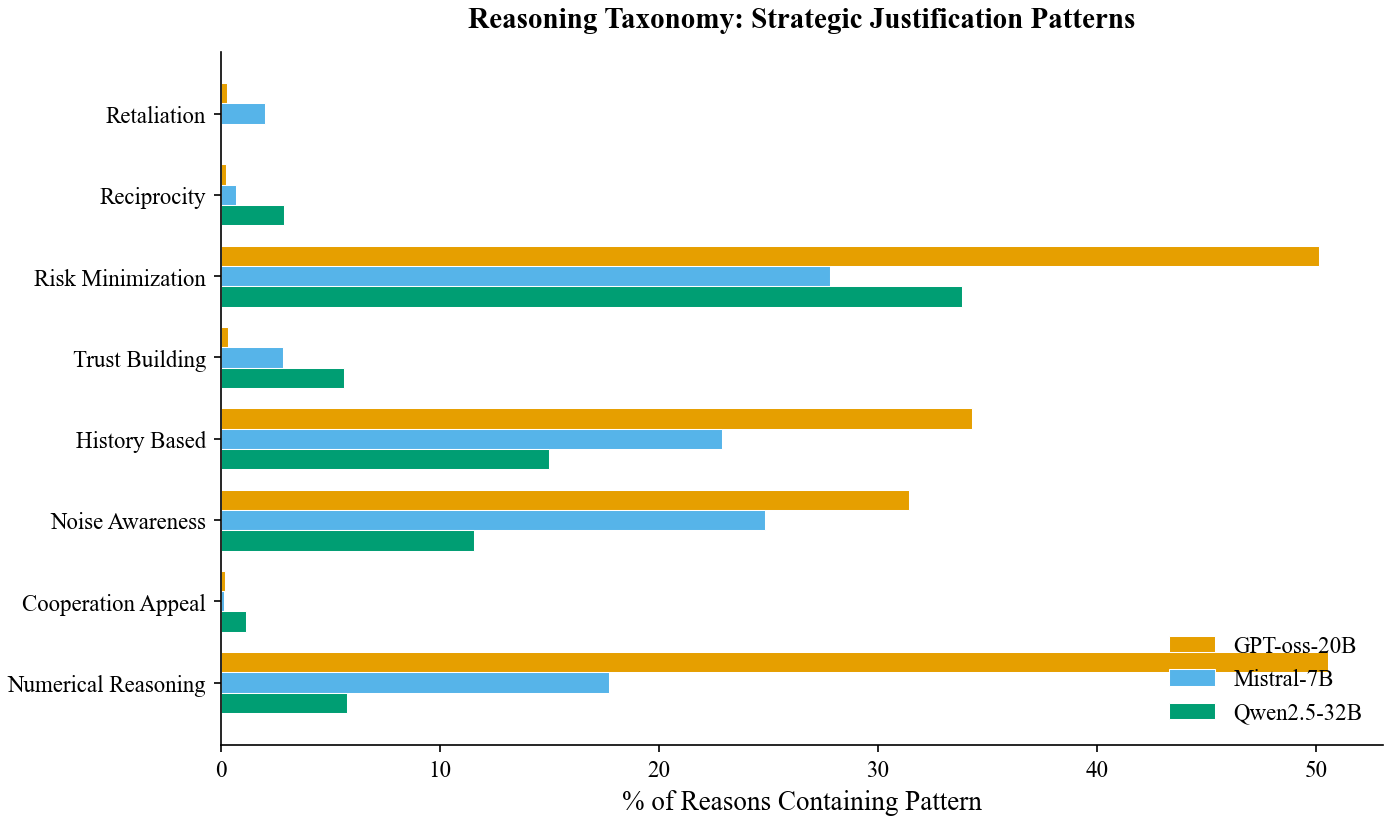

In [3]:
tax_cols = [c for c in df.columns if c.startswith('tax_')]
tax_names = [c.replace('tax_', '') for c in tax_cols]

fig, ax = plt.subplots(figsize=(10, 6))
model_data = {}
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    model_data[mname] = [sub[c].mean() * 100 for c in tax_cols]

x = np.arange(len(tax_names))
width = 0.25
colors = [MODEL_COLORS[k] for k in MODEL_KEYS]
for i, mname in enumerate(MODEL_ORDER):
    ax.barh(x + (i - 1) * width, model_data[mname], width, label=mname,
            color=colors[i], edgecolor='white', linewidth=0.5)

ax.set_yticks(x)
ax.set_yticklabels(tax_names, fontsize=11)
ax.set_xlabel('% of Reasons Containing Pattern', fontsize=13)
ax.set_title('Reasoning Taxonomy: Strategic Justification Patterns',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(frameon=False, fontsize=11, loc='lower right')
ax.invert_yaxis()

plt.savefig(f'{FIGURE_DIR}fig12a_reasoning_taxonomy.pdf')
plt.savefig(f'{FIGURE_DIR}fig12a_reasoning_taxonomy.png')
plt.show()


## Figure 12b — Reasoning Characteristics Over Rounds


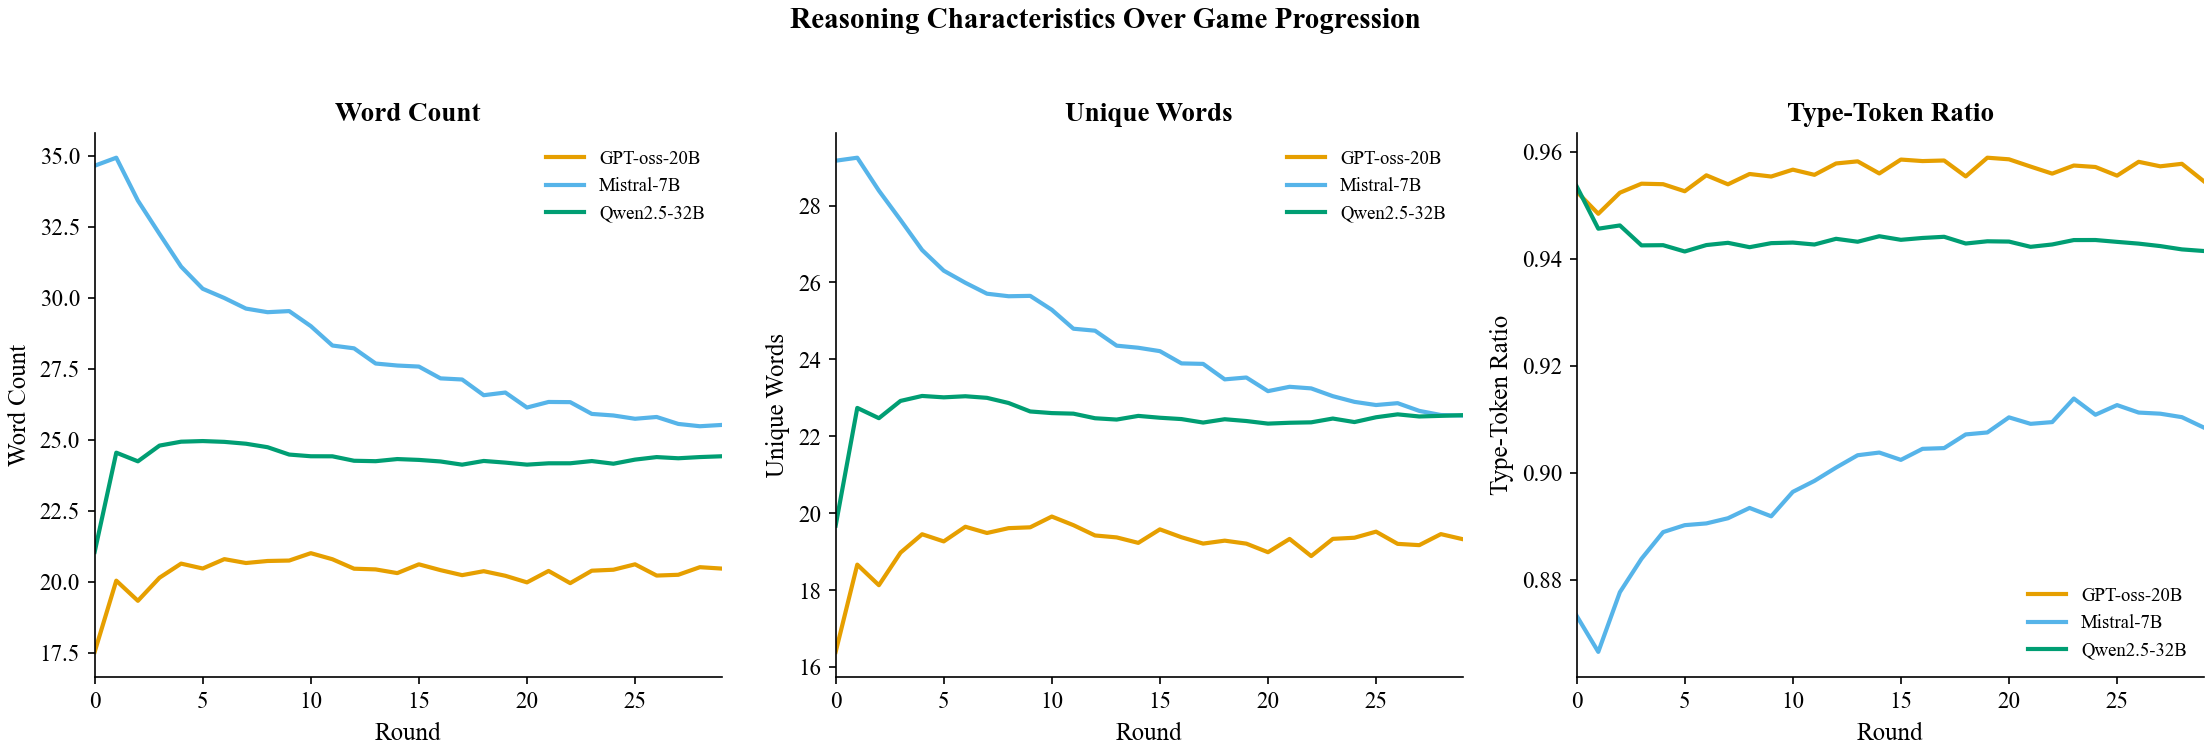

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('word_count', 'Word Count'), ('unique_words', 'Unique Words'),
           ('type_token_ratio', 'Type-Token Ratio')]
for idx, (col, label) in enumerate(metrics):
    ax = axes[idx]
    for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
        sub = df[df['llm_name'] == mkey]
        traj = sub.groupby('round_number')[col].mean()
        ax.plot(traj.index, traj.values, '-', color=MODEL_COLORS[mkey],
                label=mname, linewidth=2)
    ax.set_xlabel('Round', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(frameon=False, fontsize=9)
    ax.set_xlim(0, 29)

fig.suptitle('Reasoning Characteristics Over Game Progression',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig12b_reasoning_over_rounds.pdf')
plt.savefig(f'{FIGURE_DIR}fig12b_reasoning_over_rounds.png')
plt.show()


## Figure 12c — Say-Do Alignment: Do Reasons Match Actions?


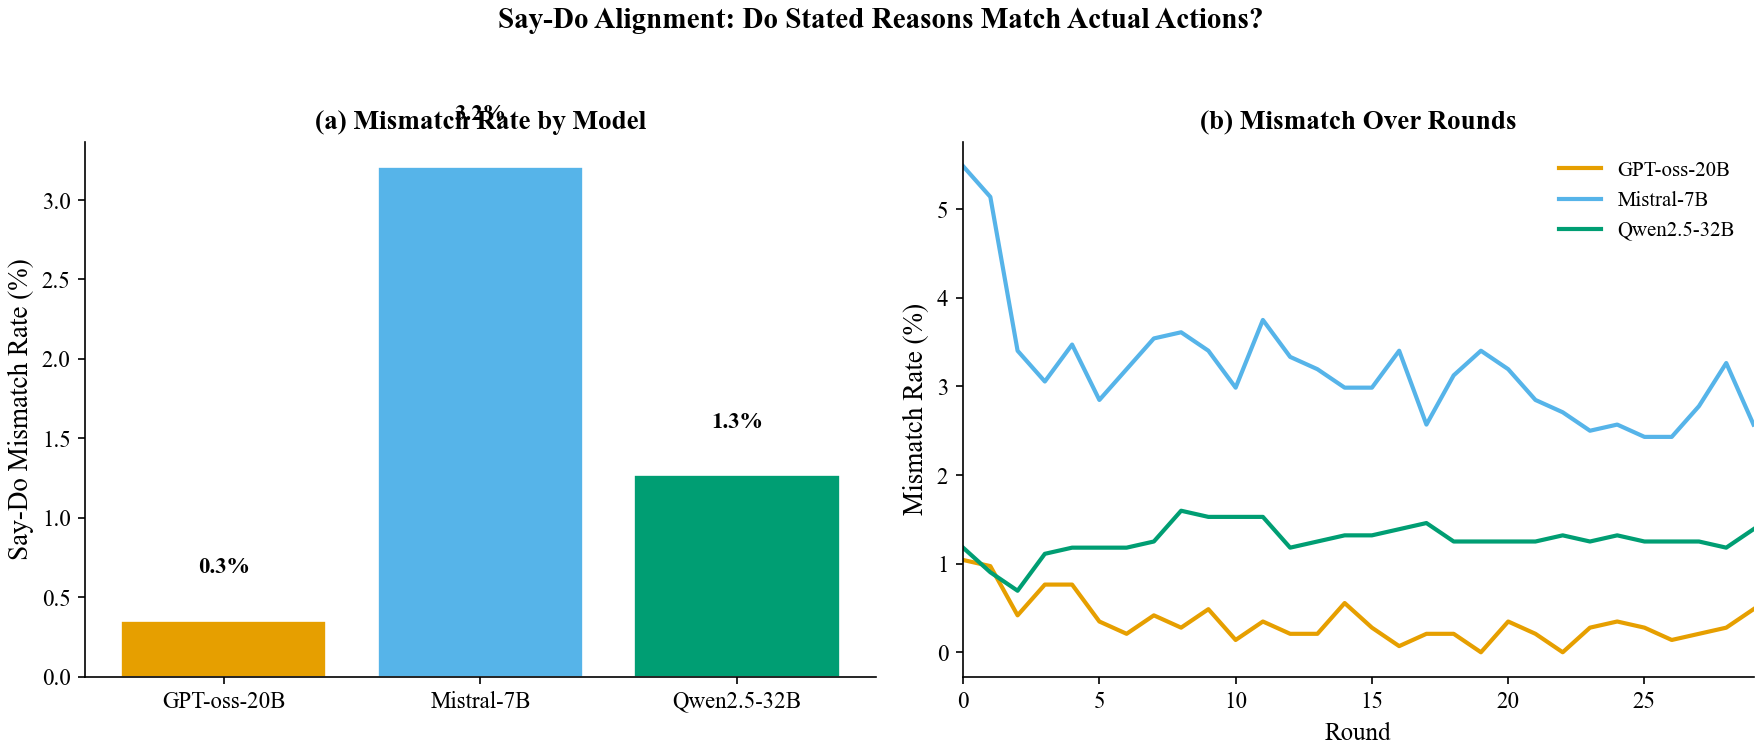

Overall say-do mismatch rate: 1.61%


In [5]:
# Detect misalignment: reason suggests cooperation but action is Defect (or vice versa)
coop_kw = r'cooperat|trust|mutual|together|benefit|encourage'
defect_kw = r'defect|betray|puni|retaliat|low.*penalty|minimiz'

df['reason_coop'] = df['reason'].str.contains(coop_kw, case=False, na=False)
df['reason_defect'] = df['reason'].str.contains(defect_kw, case=False, na=False)
df['say_do_mismatch'] = (
    (df['reason_coop'] & ~df['reason_defect'] & (df['action'] == 0)) |
    (df['reason_defect'] & ~df['reason_coop'] & (df['action'] == 1))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Mismatch rate by model
ax = axes[0]
mismatch_rates = []
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    mismatch_rates.append(sub['say_do_mismatch'].mean() * 100)
bars = ax.bar(MODEL_ORDER, mismatch_rates, color=[MODEL_COLORS[k] for k in MODEL_KEYS],
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, mismatch_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Say-Do Mismatch Rate (%)', fontsize=13)
ax.set_title('(a) Mismatch Rate by Model', fontsize=13, fontweight='bold')

# Panel B: Mismatch over rounds
ax = axes[1]
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    traj = sub.groupby('round_number')['say_do_mismatch'].mean() * 100
    ax.plot(traj.index, traj.values, '-', color=MODEL_COLORS[mkey],
            label=mname, linewidth=2)
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Mismatch Rate (%)', fontsize=13)
ax.set_title('(b) Mismatch Over Rounds', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.set_xlim(0, 29)

fig.suptitle('Say-Do Alignment: Do Stated Reasons Match Actual Actions?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig12c_say_do_alignment.pdf')
plt.savefig(f'{FIGURE_DIR}fig12c_say_do_alignment.png')
plt.show()

print(f'Overall say-do mismatch rate: {df["say_do_mismatch"].mean()*100:.2f}%')


## Figure 12d — Cross-Language Reasoning Patterns


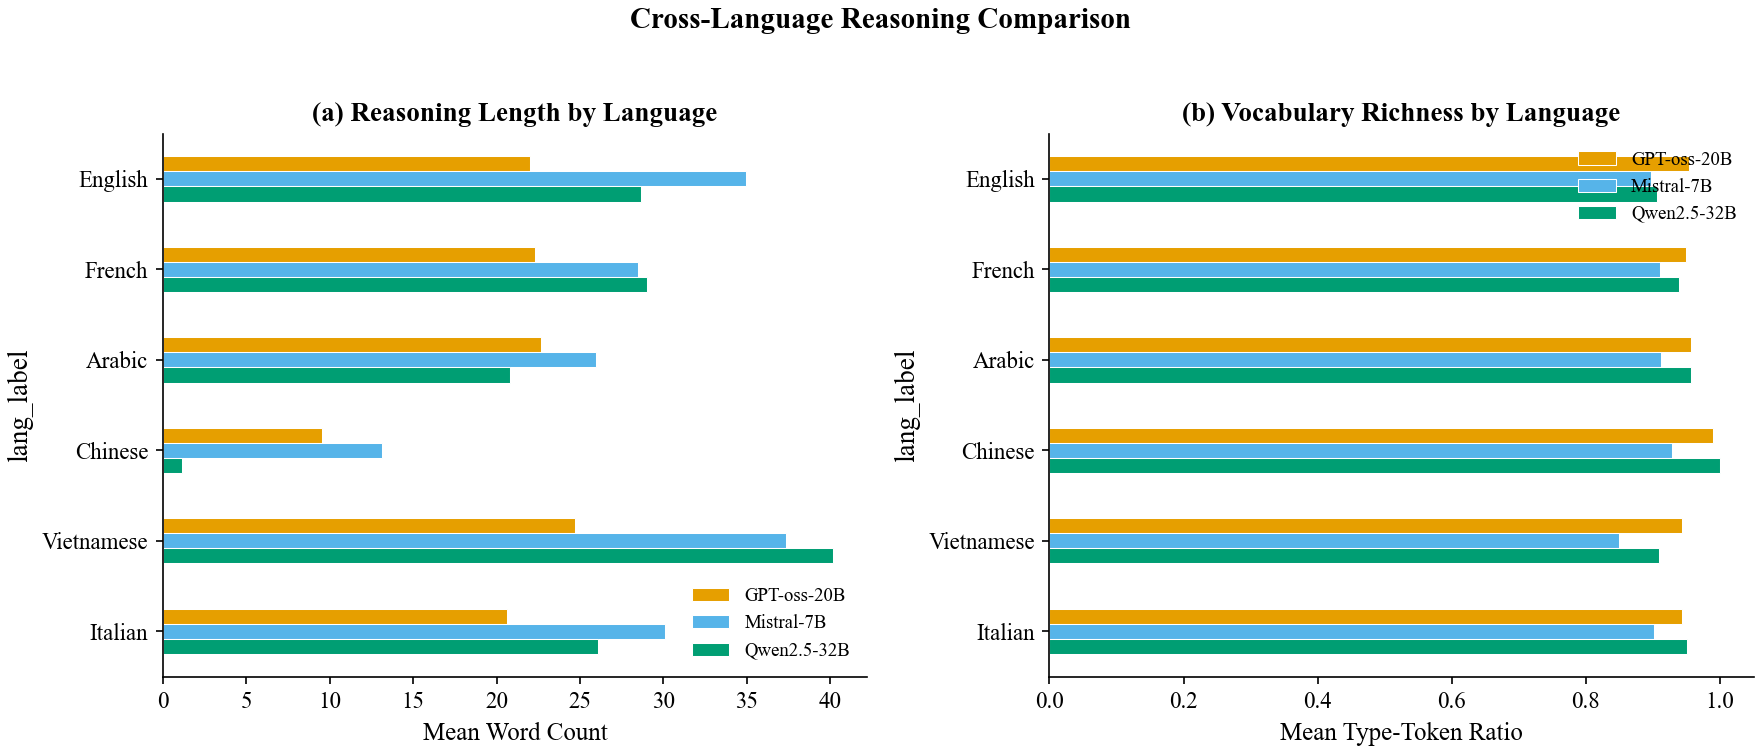

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Reason length by language
ax = axes[0]
lang_metrics = df.groupby(['lang_label', 'model'])['word_count'].mean().unstack()
lang_metrics = lang_metrics.reindex(index=LANG_ORDER, columns=MODEL_ORDER)
lang_metrics.plot(kind='barh', ax=ax, color=[MODEL_COLORS[k] for k in MODEL_KEYS],
                  edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean Word Count', fontsize=12)
ax.set_title('(a) Reasoning Length by Language', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
ax.invert_yaxis()

# Panel B: Type-token ratio by language
ax = axes[1]
ttr_metrics = df.groupby(['lang_label', 'model'])['type_token_ratio'].mean().unstack()
ttr_metrics = ttr_metrics.reindex(index=LANG_ORDER, columns=MODEL_ORDER)
ttr_metrics.plot(kind='barh', ax=ax, color=[MODEL_COLORS[k] for k in MODEL_KEYS],
                 edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean Type-Token Ratio', fontsize=12)
ax.set_title('(b) Vocabulary Richness by Language', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
ax.invert_yaxis()

fig.suptitle('Cross-Language Reasoning Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig12d_cross_language_reasoning.pdf')
plt.savefig(f'{FIGURE_DIR}fig12d_cross_language_reasoning.png')
plt.show()


## Figure 12e — Opponent Mention Frequency


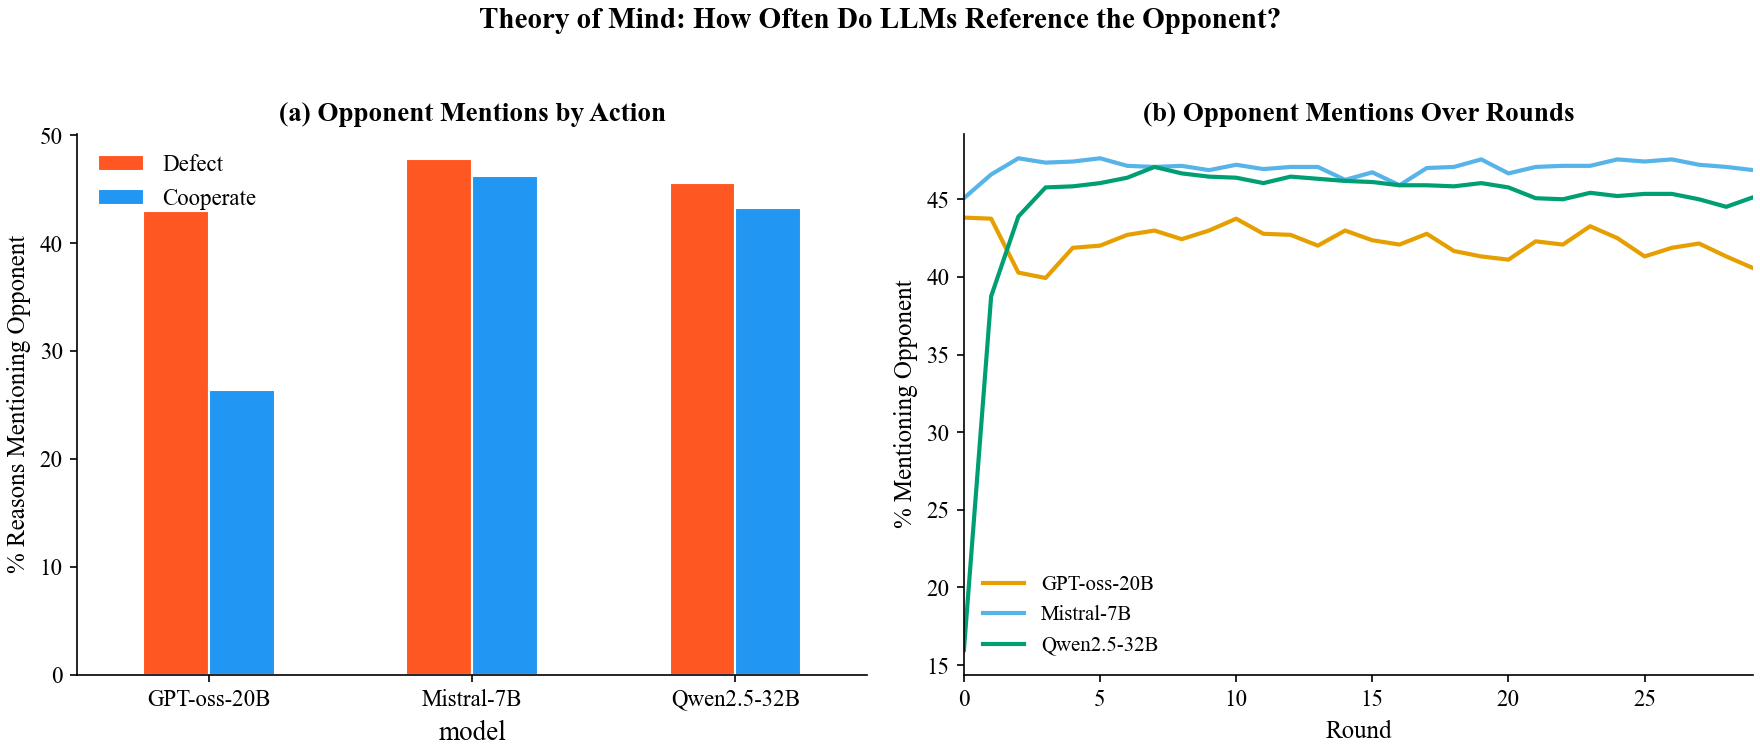

In [7]:
df['mentions_opponent'] = df['reason'].str.contains(
    r'agent.?2|opponent|other.?player|adversar', case=False, na=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: by model × action
ax = axes[0]
opp_by = df.groupby(['model', 'action'])['mentions_opponent'].mean().unstack() * 100
opp_by.columns = ['Defect', 'Cooperate']
opp_by = opp_by.reindex(MODEL_ORDER)
opp_by.plot(kind='bar', ax=ax, color=['#FF5722', '#2196F3'], edgecolor='white')
ax.set_ylabel('% Reasons Mentioning Opponent', fontsize=12)
ax.set_title('(a) Opponent Mentions by Action', fontsize=13, fontweight='bold')
ax.set_xticklabels(MODEL_ORDER, rotation=0)
ax.legend(frameon=False)

# Panel B: over rounds
ax = axes[1]
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    traj = sub.groupby('round_number')['mentions_opponent'].mean() * 100
    ax.plot(traj.index, traj.values, '-', color=MODEL_COLORS[mkey],
            label=mname, linewidth=2)
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('% Mentioning Opponent', fontsize=12)
ax.set_title('(b) Opponent Mentions Over Rounds', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.set_xlim(0, 29)

fig.suptitle('Theory of Mind: How Often Do LLMs Reference the Opponent?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig12e_opponent_mentions.pdf')
plt.savefig(f'{FIGURE_DIR}fig12e_opponent_mentions.png')
plt.show()


## Figure 12f — Sentiment Analysis: Cooperative vs. Competitive Framing


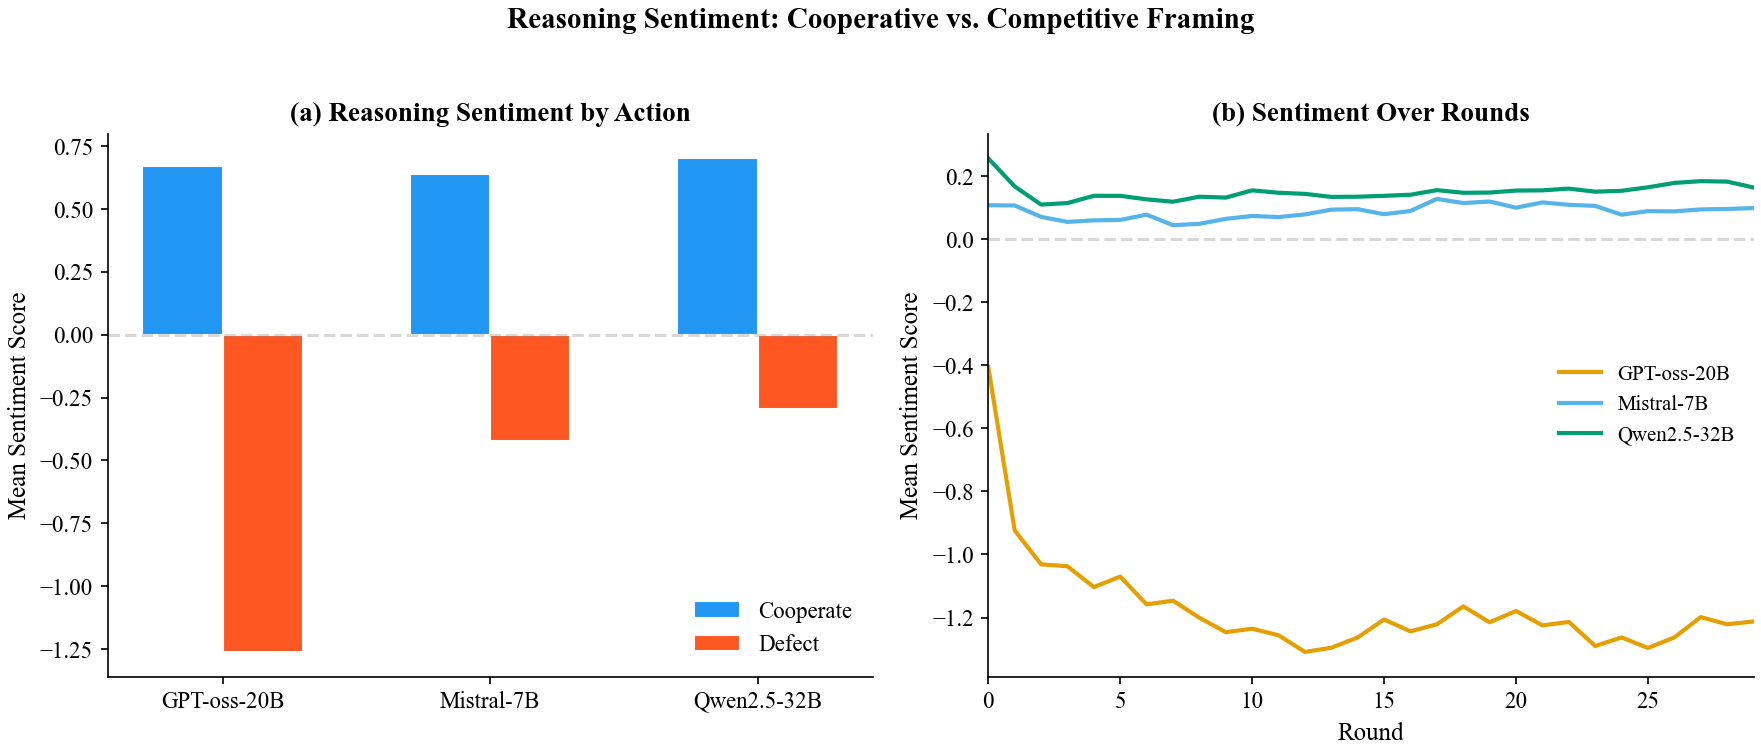

In [8]:
POS_WORDS = r'cooperat|benefit|mutual|trust|reward|good|positive|together|encourage|peace'
NEG_WORDS = r'defect|penalty|punish|risk|loss|betray|negative|threat|exploit|retaliat'

df['pos_count'] = df['reason'].str.lower().str.count(POS_WORDS)
df['neg_count'] = df['reason'].str.lower().str.count(NEG_WORDS)
df['sentiment'] = df['pos_count'] - df['neg_count']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Sentiment by action type
ax = axes[0]
means_c = [df[(df['llm_name']==mk) & (df['action']==1)]['sentiment'].mean() for mk in MODEL_KEYS]
means_d = [df[(df['llm_name']==mk) & (df['action']==0)]['sentiment'].mean() for mk in MODEL_KEYS]

x = np.arange(len(MODEL_ORDER))
width = 0.3
ax.bar(x - width/2, means_c, width, label='Cooperate', color='#2196F3', edgecolor='white')
ax.bar(x + width/2, means_d, width, label='Defect', color='#FF5722', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylabel('Mean Sentiment Score', fontsize=12)
ax.set_title('(a) Reasoning Sentiment by Action', fontsize=13, fontweight='bold')
ax.legend(frameon=False)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# Panel B: Sentiment over rounds
ax = axes[1]
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    traj = sub.groupby('round_number')['sentiment'].mean()
    ax.plot(traj.index, traj.values, '-', color=MODEL_COLORS[mkey],
            label=mname, linewidth=2)
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Mean Sentiment Score', fontsize=12)
ax.set_title('(b) Sentiment Over Rounds', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlim(0, 29)

fig.suptitle('Reasoning Sentiment: Cooperative vs. Competitive Framing',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig12f_sentiment_analysis.pdf')
plt.savefig(f'{FIGURE_DIR}fig12f_sentiment_analysis.png')
plt.show()


## Statistical Tests


In [9]:
print('=' * 70)
print('STATISTICAL ANALYSIS - Reasoning Text')
print('=' * 70)

# 1. Word count across models
groups = [df[df['llm_name']==m]['word_count'] for m in df['llm_name'].unique()]
H, p = stats.kruskal(*groups)
print(f'\n1. Word count across models (Kruskal-Wallis): H={H:.2f}, p={p:.2e}')

# 2. Type-token ratio across models
groups = [df[df['llm_name']==m]['type_token_ratio'].dropna() for m in df['llm_name'].unique()]
H, p = stats.kruskal(*groups)
print(f'\n2. Type-token ratio across models: H={H:.2f}, p={p:.2e}')

# 3. Say-do mismatch across models
print('\n3. Say-do mismatch rate:')
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    rate = sub['say_do_mismatch'].mean() * 100
    n_mm = sub['say_do_mismatch'].sum()
    print(f'   {mname}: {rate:.2f}% ({n_mm:,} mismatches)')

# 4. Chi-squared: taxonomy × model
print('\n4. Taxonomy prevalence by model:')
tax_cols = [c for c in df.columns if c.startswith('tax_')]
for tc in tax_cols:
    name = tc.replace('tax_', '')
    ct = pd.crosstab(df['model'], df[tc])
    if ct.shape[1] == 2:
        chi2, p, _, _ = stats.chi2_contingency(ct)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        prev = df[tc].mean() * 100
        print(f'   {name}: chi2={chi2:.1f}, p={p:.2e} {sig} (overall={prev:.1f}%)')

# 5. Sentiment by action
g_c = df[df['action']==1]['sentiment']
g_d = df[df['action']==0]['sentiment']
U, p = stats.mannwhitneyu(g_c, g_d, alternative='two-sided')
print(f'\n5. Sentiment: Cooperate ({g_c.mean():.3f}) vs Defect ({g_d.mean():.3f})')
print(f'   Mann-Whitney U={U:.0f}, p={p:.2e}')

# 6. Cross-language word count
print('\n6. Word count by language:')
for lang in LANG_ORDER:
    sub = df[df['lang_label']==lang]
    print(f'   {lang}: {sub["word_count"].mean():.1f} words, TTR={sub["type_token_ratio"].mean():.3f}')


STATISTICAL ANALYSIS - Reasoning Text

1. Word count across models (Kruskal-Wallis): H=11388.74, p=0.00e+00

2. Type-token ratio across models: H=12936.41, p=0.00e+00

3. Say-do mismatch rate:
   GPT-oss-20B: 0.35% (151 mismatches)
   Mistral-7B: 3.21% (1,385 mismatches)
   Qwen2.5-32B: 1.27% (547 mismatches)

4. Taxonomy prevalence by model:
   Retaliation: chi2=1326.4, p=9.36e-289 *** (overall=0.8%)
   Reciprocity: chi2=1383.0, p=4.86e-301 *** (overall=1.3%)
   Risk Minimization: chi2=4929.9, p=0.00e+00 *** (overall=37.2%)
   Trust Building: chi2=2089.3, p=0.00e+00 *** (overall=2.9%)
   History Based: chi2=4463.7, p=0.00e+00 *** (overall=24.1%)
   Noise Awareness: chi2=5058.2, p=0.00e+00 *** (overall=22.6%)
   Cooperation Appeal: chi2=546.2, p=2.48e-119 *** (overall=0.5%)
   Numerical Reasoning: chi2=24966.7, p=0.00e+00 *** (overall=24.7%)

5. Sentiment: Cooperate (0.669) vs Defect (-0.782)
   Mann-Whitney U=2870703556, p=0.00e+00

6. Word count by language:
   English: 28.5 words, T

## Summary Table


In [10]:
print('=' * 90)
print('TABLE: Reasoning Text Analysis Summary')
print('=' * 90)
print(f'{"Model":<16} | {"Words":>6} | {"TTR":>5} | {"Opp.Mention%":>12} | {"Mismatch%":>10} | {"Sentiment":>9}')
print('-' * 70)
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    wc = sub['word_count'].mean()
    ttr = sub['type_token_ratio'].mean()
    opp = sub['mentions_opponent'].mean() * 100
    mm = sub['say_do_mismatch'].mean() * 100
    sent = sub['sentiment'].mean()
    print(f'{mname:<16} | {wc:>6.1f} | {ttr:>5.3f} | {opp:>12.1f} | {mm:>10.2f} | {sent:>9.3f}')

print()
print('KEY FINDINGS:')
print('1. LLMs primarily rely on history-based reasoning and risk minimization.')
print('2. Reasoning length and vocabulary richness vary across models and languages.')
print('3. Say-do misalignment exists: some reasons suggest one action while taking another.')
print('4. Opponent mentions indicate varying levels of theory-of-mind across models.')
print('5. Cooperative actions are framed with positive language; defection with negative.')


TABLE: Reasoning Text Analysis Summary
Model            |  Words |   TTR | Opp.Mention% |  Mismatch% | Sentiment
----------------------------------------------------------------------
GPT-oss-20B      |   20.3 | 0.956 |         42.2 |       0.35 |    -1.170
Mistral-7B       |   28.3 | 0.900 |         47.0 |       3.21 |     0.087
Qwen2.5-32B      |   24.3 | 0.943 |         44.5 |       1.27 |     0.151

KEY FINDINGS:
1. LLMs primarily rely on history-based reasoning and risk minimization.
2. Reasoning length and vocabulary richness vary across models and languages.
3. Say-do misalignment exists: some reasons suggest one action while taking another.
4. Opponent mentions indicate varying levels of theory-of-mind across models.
5. Cooperative actions are framed with positive language; defection with negative.
